In [1]:
# Graph paper — three densities (regular / extra / super).
# Full grid: horizontal AND vertical lines on the canonical lattice.
# Per-density LINE_WIDTH preserves a ratio of ~4% (LINE_WIDTH/SPACING).
# Regular at LINE_WIDTH=10, SPACING=250 is the visual baseline; extra
# and super are scaled down so denser grids don't go muddy.
# CENTER_MARGIN=125 is the cross-density invariant; line CENTERS sit on
# the shared lattice regardless of thickness.
#
# Super's width is 4 px (not 5) because LINE_WIDTH must be EVEN for the
# edge margin to stay an integer. That gives a ratio of 3.2% vs the
# target 4.0% — a hair thinner relative to spacing, but visually close.
#
# Output: ../output/graph/{graph,extra-graph,super-graph}.png
from PIL import Image
from IPython.display import display
from common import (
    blank_page, draw_header, hline, vline,
    grid_counts, lattice_x, lattice_y,
    output_path, variant_name, DENSITIES,
)

MODE = "graph"

# ratio = LINE_WIDTH / SPACING = 10/250 = 4%   (regular is the reference)
LINE_WIDTHS = {
    "regular": 10,   # 10/250 = 4.0%
    "extra":   6,    #  6/150 = 4.0%
    "super":   4,    #  4/125 = 3.2%  (5 would be ideal but breaks parity)
}

In [2]:
def render_graph(spacing, line_width):
    """Vertical lines at every column, horizontal lines at every row.
    Intersections are pixel-aligned squares filled by both passes —
    they tile cleanly with no AA artifacts."""
    img = blank_page()
    n_x, n_y = grid_counts(spacing)
    for i in range(n_x):
        vline(img, lattice_x(i, spacing, line_width), thickness=line_width)
    for j in range(n_y):
        hline(img, lattice_y(j, spacing, line_width), thickness=line_width)
    draw_header(img)
    return img, n_x, n_y

regular  spacing=250  lw=10  34×43 grid  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/graph/graph.png


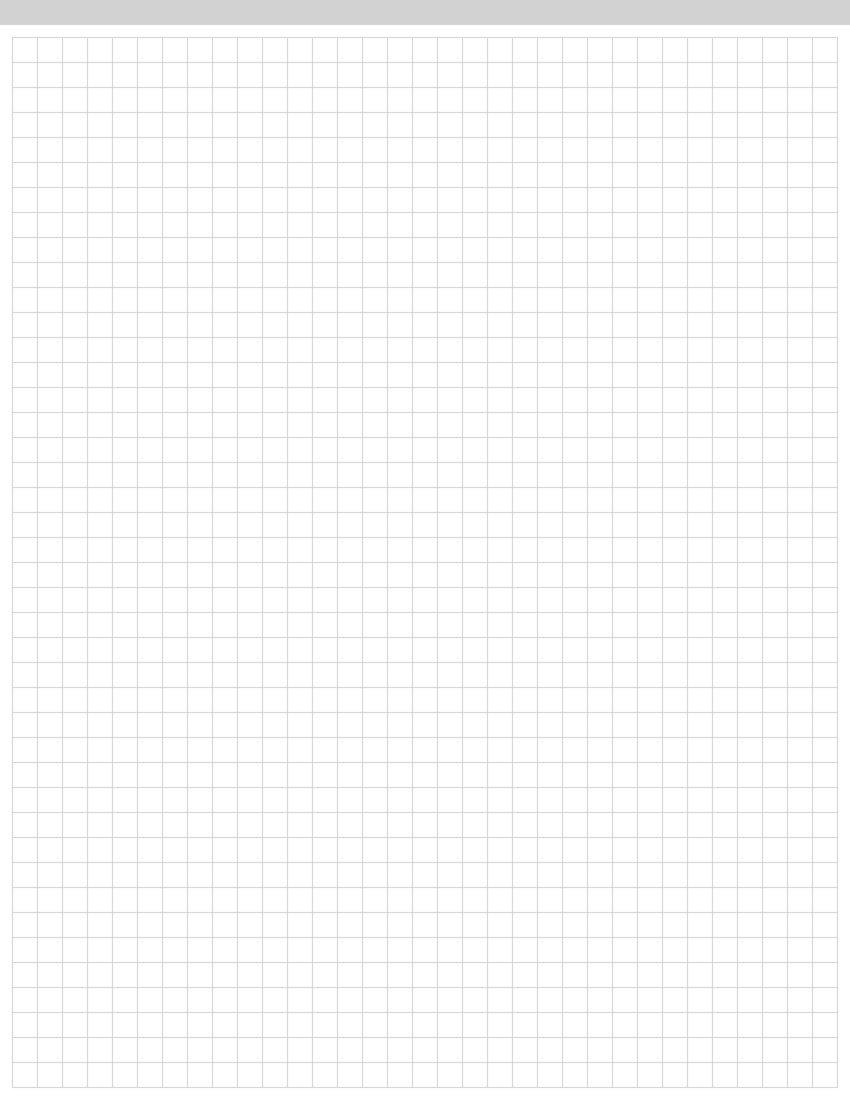

extra    spacing=150  lw= 6  56×71 grid  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/graph/extra-graph.png


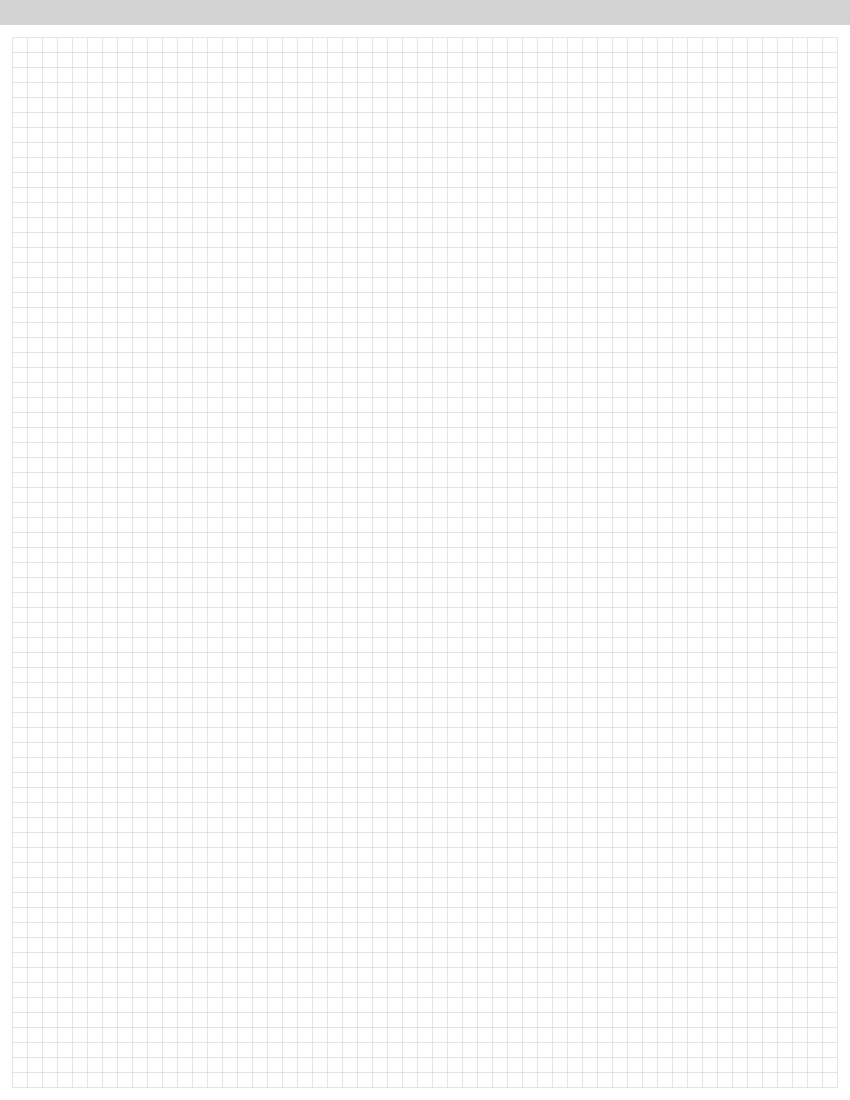

super    spacing=125  lw= 4  67×85 grid  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/graph/super-graph.png


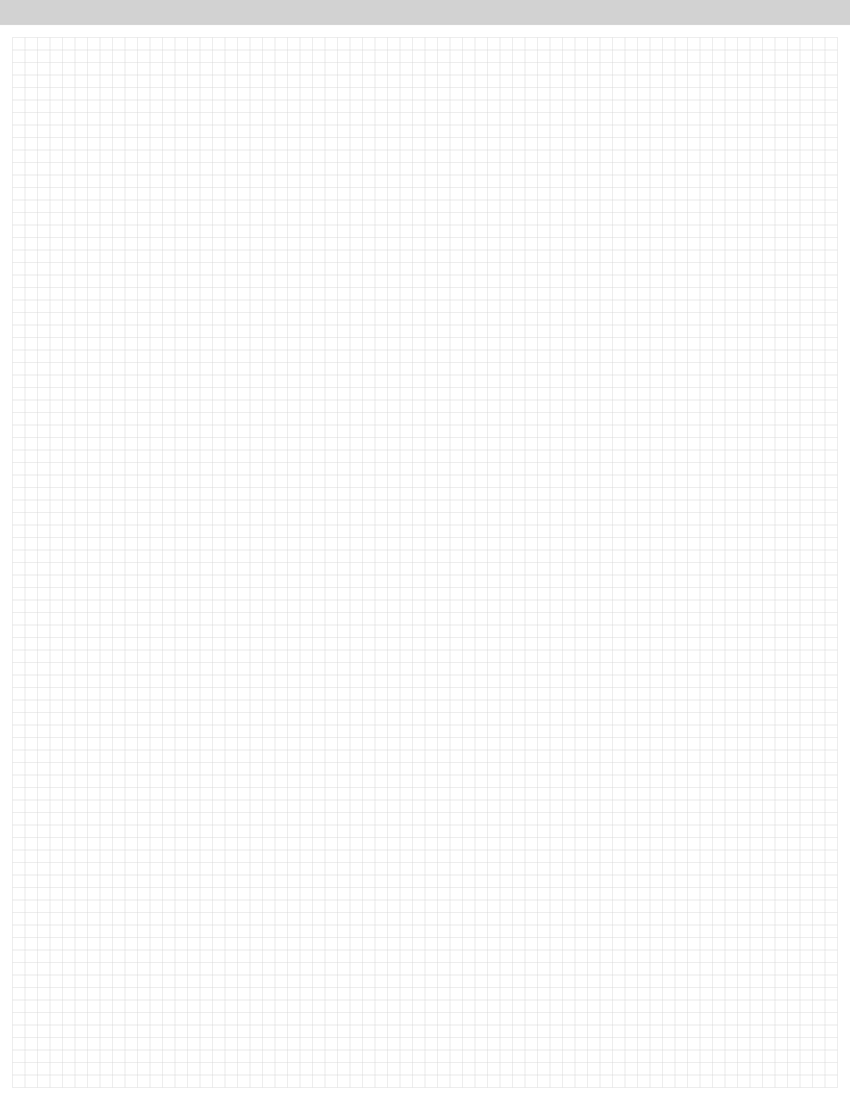

In [3]:
for density, spacing in DENSITIES.items():
    lw = LINE_WIDTHS[density]
    img, n_x, n_y = render_graph(spacing, lw)
    path = output_path(MODE, variant_name(MODE, density))
    img.save(path, "PNG")
    print(
        f"{density:8s} spacing={spacing:3d}  lw={lw:2d}  "
        f"{n_x}×{n_y} grid  →  {path}"
    )
    display(img.resize((850, 1100), Image.LANCZOS))